# Future Risk

Here we run a calculation for future risk, looking at how growth and climate change affect future modelled impacts.

In this notebook we will

- Create a future Entity object, where future assets are created from present-day assets, with scaled values according to projected growth.
- Read a future Hazard object, based on future climate simulations
- Create a waterfall plot breaking down future changes in risk into growth and climate change components.

Here we examine risks to Maize production.

In [21]:
# -------------------------------
# Specify parameters for the analysis
# -------------------------------

YEAR_PRESENT = 2025
YEAR_FUTURE = 2038

In [22]:
from pathlib import Path

# -------------------------------
# Set up paths to data
# -------------------------------

# Set up paths to data
ENTITY_DIR = "../data/entity_files_calibrated/"
ENTITY_FILE = "El_Salvador_Entity_Drought_Maize_calibrated.xlsx"
entity_filepath = Path(ENTITY_DIR) / ENTITY_FILE

HAZARD_DIR = "../data/hazard/annual/"
HAZARD_PRESENT_FILE = "ElSalvador_SPEI12_present_maize.tif"
HAZARD_FUTURE_FILE = "ElSalvador_SPEI12_future_maize.tif"
haz_present_filepath = Path(HAZARD_DIR) / HAZARD_PRESENT_FILE
haz_future_filepath = Path(HAZARD_DIR) / HAZARD_FUTURE_FILE

# Socioeconomic growth projections
GROWTH_RATES_FILEPATH = "../data/socioeconomic_change/growth_projections.csv"


## Create present-day and future Entity objects

### Read in present-day Entity file

In [23]:
import copy
from climada.entity import Entity

# Read the Entity file and set additional metadata for the Exposures
print(f"Reading {entity_filepath}...")
entity_present = Entity.from_excel(entity_filepath)
entity_present.exposures.ref_year = YEAR_PRESENT
entity_present.exposures.value_unit = "kg"
entity_present.exposures.description = f"Maize Production (Present, {YEAR_PRESENT})"

Reading ../data/entity_files_calibrated/El_Salvador_Entity_Drought_Maize_calibrated.xlsx...


### Apply projected growth to Exposures

There are two ways to create a future Entity object: directly in an Excel file, or by making adjustments in code. In general only the Exposures change between present-day and future Entity objects: everything else (impact functions, discount rates, measures) should remain the same. Otherwise you may get unexpected behavior.

In this analysis, our future assets are created by scaling present-day asset values. Their geographic location remains the same. This is most easily done in code (and saves us from updating two versions of the Entity file when we make changes to other sheets in the file).


In [24]:
import pandas as pd

# Load growth rate data
growth_rates_df = pd.read_csv(GROWTH_RATES_FILEPATH).set_index("Year")

# Filter to years between present and future
growth_rates_df = growth_rates_df.loc[(growth_rates_df.index > YEAR_PRESENT) & (growth_rates_df.index <= YEAR_FUTURE)]
display(growth_rates_df)


,GDP Growth Rate
Year,
2026,0.025
2027,0.025
2028,0.025
2029,0.025
2030,0.025
2031,0.025
2032,0.025
2033,0.025
2034,0.025


In [25]:
import numpy as np

# Calculate the total growth over the whole study period
growth_factor_gdp = np.prod(1 + growth_rates_df["GDP Growth Rate"].values)
print(f"GDP increase from present: {(growth_factor_gdp - 1) * 100:.2f}%")

GDP increase from present: 37.85%


In [26]:
# -------------------------------
# Create the future Entity
# -------------------------------

# Copy the present-day Entity
entity_future = copy.deepcopy(entity_present)

# Apply the GDP growth factor to the exposure values
entity_future.exposures.gdf["value"] = entity_future.exposures.gdf["value"] * growth_factor_gdp

# Update the reference year for the future Entity
entity_future.exposures.ref_year = YEAR_FUTURE
entity_future.exposures.description = f"Maize Production (Future, {YEAR_FUTURE})"

print("Future exposure created")
print(f"GDP increase %: {(growth_factor_gdp - 1) * 100:.2f}%")
print(f"Present-day exposure value: {entity_present.exposures.gdf['value'].sum():,.0f} kg")
print(f"Future exposure value: {entity_future.exposures.gdf['value'].sum():,.0f} kg")


Future exposure created
GDP increase %: 37.85%
Present-day exposure value: 788,391,516 kg
Future exposure value: 1,086,806,412 kg


<GeoAxes: title={'center': 'Maize Production (Future, 2038)'}>

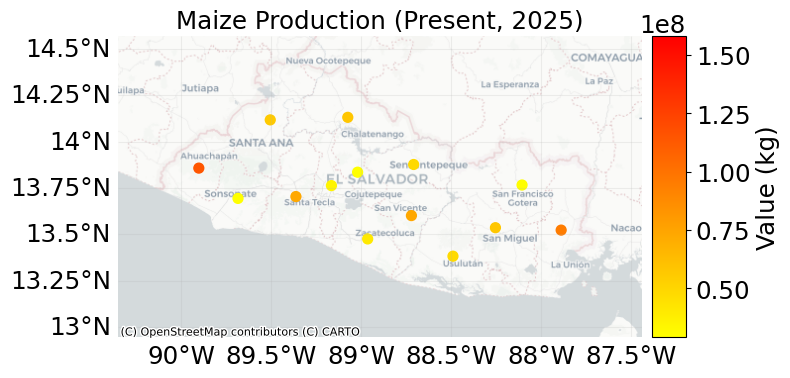

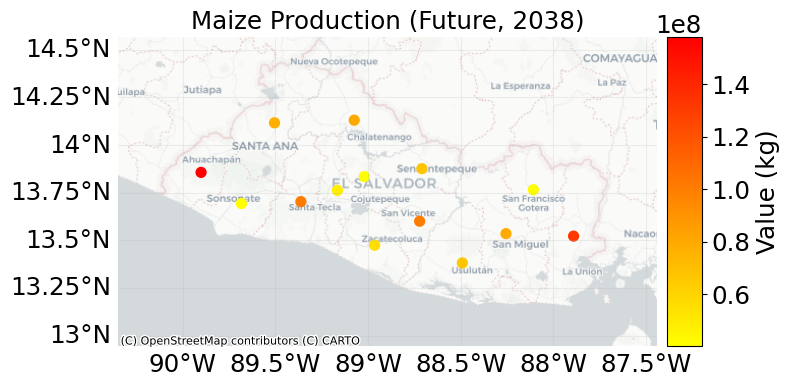

In [27]:
# -------------------------------
# Plot the Exposures
# -------------------------------

max_value = entity_future.exposures.gdf["value"].max()
entity_present.exposures.plot_basemap(
        title=entity_present.exposures.description,
        ignore_zero=True,        # Whether to plot points with zero value
        buffer=50000,            # Add a buffer around the points to show a larger map region (measured in meters)
        s=50,                    # The size of point markers on the plot
        zoom=8,                  # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=max_value,          # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)          # Dimensions of the output figure
    )
entity_future.exposures.plot_basemap(
        title=entity_future.exposures.description,
        ignore_zero=True,        # Whether to plot points with zero value
        buffer=50000,            # Add a buffer around the points to show a larger map region (measured in meters)
        s=50,                    # The size of point markers on the plot
        zoom=8,                  # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=max_value,          # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)
)

## Create present-day and future Hazard objects

### Read present-day hazard data

In [28]:
from climada.hazard import Hazard

n_years_data_present = 54   # 1972 to 2025 inclusive
event_frequency_present = 1 / n_years_data_present

haz_present = Hazard.from_raster(
    files_intensity = haz_present_filepath,
    band=list(np.arange(n_years_data) + 1),
    attrs={
        'unit': 'SPEI',   # as an index the SPEI has no units – so we can specify this or an empty string, as long as it is consistent with the Entity file Impact Functions
        'event_name': [str(year) for year in np.arange(1972, 2026)],     # We can optionally name the events
        'frequency': np.full(n_years_data_present, event_frequency_present)              # Define the frequency of each event
    },
    haz_type='DR'
)
haz_present.intensity[haz_present.intensity > 0] = 0     # Set positive drought indices to zero to speed up calculation 

2026-07-03 18:34:36,459 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_maize.tif
2026-07-03 18:34:36,465 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_maize.tif


### Read future Hazard data

In this study, we have simulated drought intensities for the present-day climate and the future climate from the same climate model. The drought information in them is consistent, meaning that our calibrated impact functions will work well with both.

In [29]:
n_years_data_future = 25   # 2026 to 2050 inclusive
event_frequency_future = 1 / n_years_data_future

haz_future = Hazard.from_raster(
    files_intensity = haz_future_filepath,
    band=list(np.arange(n_years_data_future) + 1),
    attrs={
        'unit': 'SPEI',   # as an index the SPEI has no units – so we can specify this or an empty string, as long as it is consistent with the Entity file Impact Functions
        'event_name': [str(year) for year in np.arange(2026, 2051)],     # We can optionally name the events
        'frequency': np.full(n_years_data_future, event_frequency_future)              # Define the frequency of each event
    },
    haz_type='DR'
)
haz_future.intensity[haz_future.intensity > 0] = 0     # Set positive drought indices to zero to speed up calculation 


2026-07-03 18:34:40,142 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_future_maize.tif
2026-07-03 18:34:40,148 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_future_maize.tif


In [30]:
# ------------------------------------------
# Assign hazard centroids to the exposures
# ------------------------------------------

entity_present.exposures.assign_centroids(haz_present, overwrite=True)
entity_future.exposures.assign_centroids(haz_future, overwrite=True)

2026-07-03 18:34:47,021 - climada.entity.exposures.base - INFO - Matching 14 exposures with 15 centroids.
2026-07-03 18:34:47,025 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 1.0 degree
2026-07-03 18:34:47,030 - climada.entity.exposures.base - INFO - Matching 14 exposures with 15 centroids.
2026-07-03 18:34:47,032 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 1.0 degree


## Show components of changing risk in a waterfall plot

One of the most useful visualizations for how modelled risk changes between present-day and future climates is the waterfall plot. It breaks down the change into change driven by growth, and change from climate change. In the calculation, that means change from the future Entity and change from the future Hazard objects.

The plot is generated from the `CostBenefit.plot_waterfall` method (but doesn't use Measures).

2026-07-03 18:35:06,981 - climada.engine.impact_calc - INFO - Calculating impact for 70 assets (>0) and 54 events.
2026-07-03 18:35:06,988 - climada.engine.impact_calc - INFO - Calculating impact for 70 assets (>0) and 25 events.
2026-07-03 18:35:07,016 - climada.engine.cost_benefit - INFO - Risk at 2025: 5.320e+07
2026-07-03 18:35:07,018 - climada.engine.impact_calc - INFO - Calculating impact for 70 assets (>0) and 54 events.
2026-07-03 18:35:07,025 - climada.engine.cost_benefit - INFO - Risk with development at 2038: 7.333e+07
2026-07-03 18:35:07,026 - climada.engine.cost_benefit - INFO - Risk with development and climate change at 2038: 2.735e+08


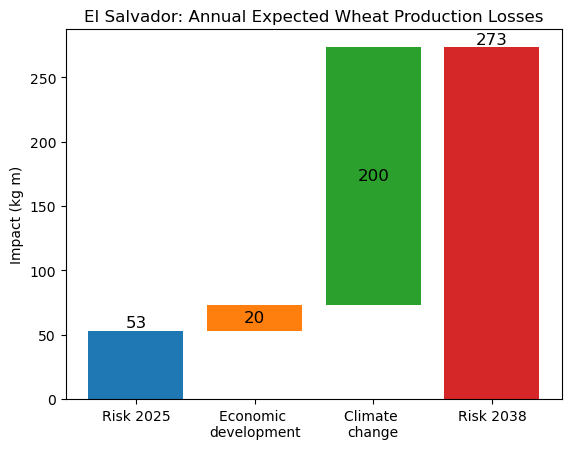

In [32]:
from climada.engine import CostBenefit

cb = CostBenefit()

ax = cb.plot_waterfall(
    haz_present,
    entity_present,
    haz_future,
    entity_future
)
ax = ax.set_title("El Salvador: Annual Expected Wheat Production Losses")

The three components of the average annual risk shown in the plot come from three Impact calculations run by CLIMADA:

- Baseline risk (present-day Hazard and present-day Entity)
- Economic development (calculating the difference from baseline to risk with present-day Hazard and future Entity)
- Economic development + climate change (calculating the difference from only economic change to risk with future Hazard and future Entity)

Note that the 'climate change' component is applied _on top of_ the economic growth.


## Compare present-day and future risk

We can compare the changes in modelled risk by calculating the Impacts for present and future climates.

In [34]:
from climada.engine import ImpactCalc

# ------------------------------------------
# Run impact calculations for present and future scenarios
# ------------------------------------------

impact_present = ImpactCalc(
    entity_present.exposures,
    entity_present.impact_funcs,
    haz_present
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

impact_future = ImpactCalc(
    entity_future.exposures,
    entity_future.impact_funcs,
    haz_future
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

print(f"Present-day annual expected production loss: {impact_present.aai_agg:,.0f} kg")
print(f"Future annual expected production loss: {impact_future.aai_agg:,.0f} kg")

2026-07-03 18:36:25,904 - climada.engine.impact_calc - INFO - Calculating impact for 42 assets (>0) and 54 events.
2026-07-03 18:36:25,912 - climada.engine.impact_calc - INFO - Calculating impact for 42 assets (>0) and 25 events.
Present-day annual expected production loss: 53,198,268 kg
Future annual expected production loss: 273,470,722 kg


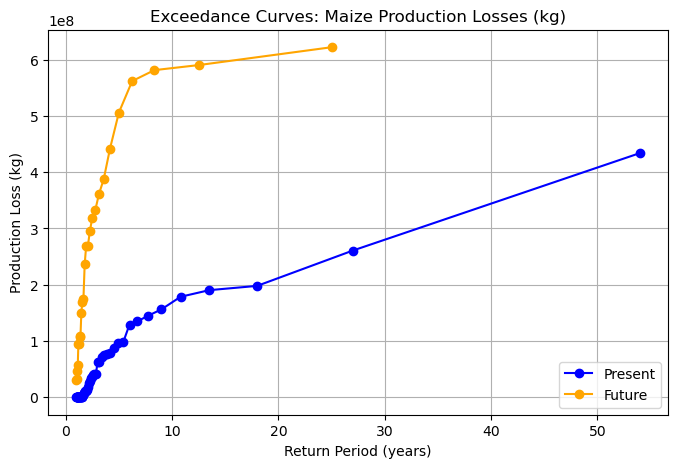

In [36]:
import matplotlib.pyplot as plt

# ---------------------------
# Compare Exceedance curves
# ---------------------------

exceedance_present = impact_present.calc_freq_curve()
exceedance_future = impact_future.calc_freq_curve()

fig, axis = plt.subplots(figsize=(8, 5))
exceedance_present.plot(axis=axis, color="blue", marker="o", label="Present")
exceedance_future.plot(axis=axis, color="orange", marker="o", label="Future")
axis.set_title("Exceedance Curves: Maize Production Losses (kg)")
axis.set_xlabel("Return Period (years)")
axis.set_ylabel("Production Loss (kg)")
plt.grid(True)
axis.legend(loc="lower right")
plt.show()
plt.close(axis.figure)


This plot summarizes the dramatic changes from combined economic growth (effectively scaling along the y-axis) and climate change (as droughts intensify). The future exceedance curve is dramatically higher than the present-day exceedance.

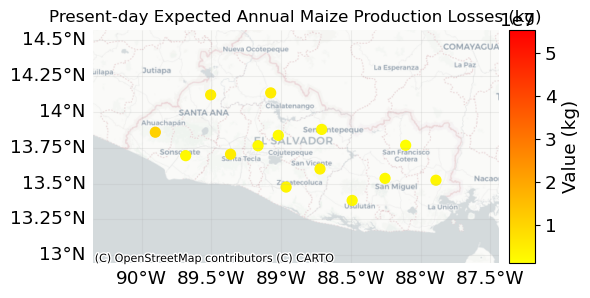

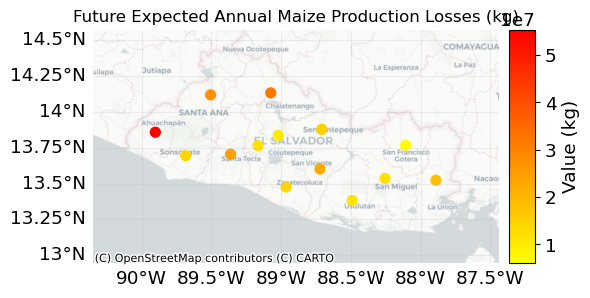

In [39]:
import contextily as ctx

# ----------------------------
# Map expected annual impacts
# ----------------------------

max_impact = impact_future.eai_exp.max()

axis = impact_present.plot_basemap_eai_exposure(
    ignore_zero=True,                   # Don't plot locations with zero impacts
    pop_name=False,                     # Don't plot place names
    buffer=50000,                         # Add spatial buffers to the map (in the CRS coordinate units)
    s=50,                                # The size of point markers on the plot
    zoom=8,                            # Level of detail to add to the basemap
    cmap="autumn_r",                    # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
    vmax=max_impact,                    # Set the maximum value for the colour scale
    url=ctx.providers.CartoDB.Positron, # Basemap provider
    figsize=(6, 8)
)
axis.set_title(f"Present-day Expected Annual Maize Production Losses (kg)")
plt.show()
plt.close(axis.figure)

axis = impact_future.plot_basemap_eai_exposure(
    ignore_zero=True,                   # Don't plot locations with zero impacts
    pop_name=False,                     # Don't plot place names
    buffer=50000,                         # Add spatial buffers to the map (in the CRS coordinate units)
    s=50,                                # The size of point markers on the plot
    zoom=8,                            # Level of detail to add to the basemap
    cmap="autumn_r",                    # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
    vmax=max_impact,                    # Set the maximum value for the colour scale
    url=ctx.providers.CartoDB.Positron, # Basemap provider
    figsize=(6, 8)
)
axis.set_title(f"Future Expected Annual Maize Production Losses (kg)")
plt.show()
plt.close(axis.figure)


### Further exploration of the breakdown of risk

By running different Impact calculations, we can explore how changes to hazard and exposures drive changes in the risk calculation.

Here we show four risk calculations, each for different components of risk. (Some of these we did already but we show them again for completeness.). We can then summarize the results in a table and generate a more detailed waterfall plot.

In [41]:
# 1. Present-day exposure + present-day hazard
impact_present_present = ImpactCalc(
    entity_present.exposures,
    entity_present.impact_funcs,
    haz_present
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

# 2. Future exposure + present-day hazard
impact_future_exp_only = ImpactCalc(
    entity_future.exposures,
    entity_future.impact_funcs,
    haz_present
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

# 3. Present-day exposure + future hazard
impact_future_haz_only = ImpactCalc(
    entity_present.exposures,
    entity_present.impact_funcs,
    haz_future
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

# 4. Future exposure + future hazard
impact_future_combined = ImpactCalc(
    entity_future.exposures,
    entity_future.impact_funcs,
    haz_future
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

decomp_df = pd.DataFrame({
    "Scenario": [
        "Present-day exposure + present-day hazard",
        "Future exposure + present-day hazard",
        "Present-day exposure + future hazard",
        "Future exposure + future hazard"
    ],
    "Average annual impact (kg)": [
        impact_present_present.aai_agg,
        impact_future_exp_only.aai_agg,
        impact_future_haz_only.aai_agg,
        impact_future_combined.aai_agg
    ]
})

decomp_df["% increase from baseline"] = (
    decomp_df["Average annual impact (kg)"]
    / decomp_df["Average annual impact (kg)"].iloc[0]
    - 1
) * 100

numeric_cols = decomp_df.select_dtypes(include="number").columns
display(
    decomp_df.style.format({
        "Average annual impact (kg)": "{:,.0f}",
        "% increase from baseline": "{:.2f}%"
    })
)


2026-07-03 18:45:19,059 - climada.engine.impact_calc - INFO - Calculating impact for 42 assets (>0) and 54 events.
2026-07-03 18:45:19,073 - climada.engine.impact_calc - INFO - Calculating impact for 42 assets (>0) and 54 events.
2026-07-03 18:45:19,079 - climada.engine.impact_calc - INFO - Calculating impact for 42 assets (>0) and 25 events.
2026-07-03 18:45:19,086 - climada.engine.impact_calc - INFO - Calculating impact for 42 assets (>0) and 25 events.


,Scenario,Average annual impact (kg),% increase from baseline
0,Present-day exposure + present-day hazard,"53,198,268",0.00%
1,Future exposure + present-day hazard,"73,334,399",37.85%
2,Present-day exposure + future hazard,"198,381,234",272.91%
3,Future exposure + future hazard,"273,470,722",414.06%


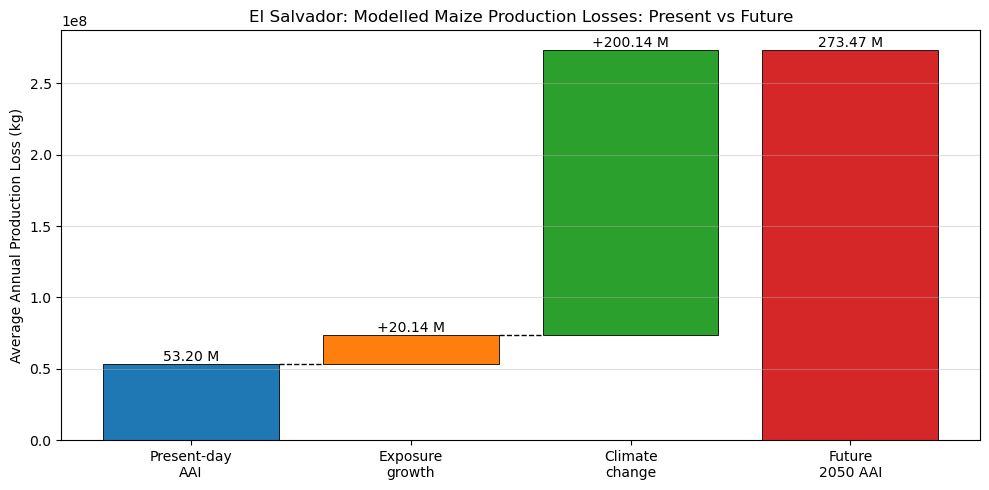

In [43]:

# ---------------------------------------
# Create a more detailed waterfall plot
# ---------------------------------------

# Gather the data we need

baseline_aai = impact_present_present.aai_agg
exp_only_aai = impact_future_exp_only.aai_agg
combined_aai = impact_future_combined.aai_agg

exposure_growth_effect = exp_only_aai - baseline_aai
climate_change_effect = combined_aai - exp_only_aai

components = [
    "Present-day\nAAI",
    "Exposure\ngrowth",
    "Climate\nchange",
    "Future\n2050 AAI"
]

heights = [
    baseline_aai,
    exposure_growth_effect,
    climate_change_effect,
    combined_aai
]

bottoms = [
    0,
    baseline_aai,
    baseline_aai + exposure_growth_effect,
    0
]

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red"
]

# Build the plot!

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    np.arange(len(components)),
    heights,
    bottom=bottoms,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

running_totals = [
    baseline_aai,
    baseline_aai + exposure_growth_effect,
    combined_aai
]

for i in range(len(running_totals) - 1):
    ax.plot(
        [i + 0.4, i + 1 - 0.4],
        [running_totals[i], running_totals[i]],
        color="black",
        linestyle="--",
        linewidth=1
    )

for i, (bottom, height) in enumerate(zip(bottoms, heights)):
    if i == 0 or i == len(components) - 1:
        label_y = height
        label_text = f"{height / 1e6:.2f} M"
    else:
        label_y = bottom + height
        label_text = f"+{height / 1e6:.2f} M"

    ax.text(
        i,
        label_y,
        label_text,
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xticks(np.arange(len(components)))
ax.set_xticklabels(components)
ax.set_ylabel("Average Annual Production Loss (kg)")
ax.set_title("El Salvador: Modelled Maize Production Losses: Present vs Future")
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

waterfall_plot_df = pd.DataFrame({
    "component": [
        "Present-day AAI",
        "Exposure growth",
        "Climate change",
        "Future 2050 AAI"
    ],
    "value_kg": heights,
    "bottom_kg": bottoms
})


### Extensions to this notebook

Note: this is a first version of the notebook. It should give you enough information to build and run your own future risk analyses.

There are still a few improvements to make to the data:
- use all three asset types
- use projected socioeconomic change information to estimate future asset values
- use longer future hazard time series
- more scientifically-grounded estimations of the changes of drought risk – this seems very high!
